<a href="https://colab.research.google.com/github/Rahuldeb55/internship26/blob/main/Week5_Data_Visualization_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 Task: Data Visualization and Communication

**Objective:** Transform complex data insights into clear, effective visual representations and communicate findings through a cohesive narrative.

For this portfolio, we will explore the **Palmer Penguins dataset**. This dataset contains size measurements, clutch observations, and blood isotope ratios for three penguin species observed on three islands in the Palmer Archipelago, Antarctica.

## 1. Storyboard and Narrative Outline

Our narrative aims to answer a core biological question: **How do physical characteristics differ among penguin species, and is geography a defining factor?**

**Storyboard:**
1. **Geographic Distribution (The "Where"):** Establish the context by mapping the population distribution of the three species across the three islands.
2. **Physical Dimorphism (The "What"):** Explore the relationship between flipper length and body mass to identify distinct physical clusters among species.
3. **Anatomical Nuances (The "Details"):** Dive deeper into bill (culmen) dimensions using a comparative distribution plot to highlight subtle evolutionary traits.
4. **Feature Correlation (The "Synthesis"):** Conclude with a correlation heatmap summarizing how all physical metrics relate to one another.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid", palette="deep")

# Load the penguins dataset
penguins = sns.load_dataset("penguins")
penguins = penguins.dropna() # Drop missing values for clean visualization

print(f"Dataset ready. Shape: {penguins.shape}")
penguins.head()

Dataset ready. Shape: (333, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


## 2. Visualizations and Narrative

### Visualization 1: Geographic Distribution of Species
Before analyzing physical traits, we must understand the geographic layout of our populations. We use a grouped bar chart to display the count of each species across the three islands.

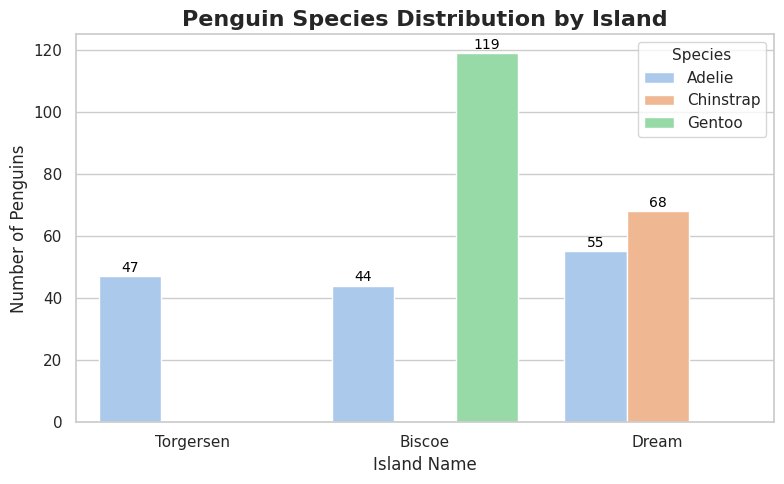

In [2]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=penguins, x='island', hue='species', palette='pastel')
plt.title('Penguin Species Distribution by Island', fontsize=16, weight='bold')
plt.xlabel('Island Name', fontsize=12)
plt.ylabel('Number of Penguins', fontsize=12)
plt.legend(title='Species', title_fontsize='11')

# Annotate bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

**Narrative Insight:**
The visualization clearly illustrates that the **Adelie** species is geographically ubiquitous, residing on all three islands. In contrast, **Gentoo** and **Chinstrap** penguins are isolated to Biscoe and Dream islands, respectively. This geographic isolation suggests that Biscoe and Dream might offer highly specific ecological niches favored by Gentoo and Chinstrap penguins.

### Visualization 2: Physical Clusters (Flipper Length vs. Body Mass)
To investigate physical differences, we plot Body Mass against Flipper Length. A scatterplot with species-encoded colors naturally reveals clustering behaviors.

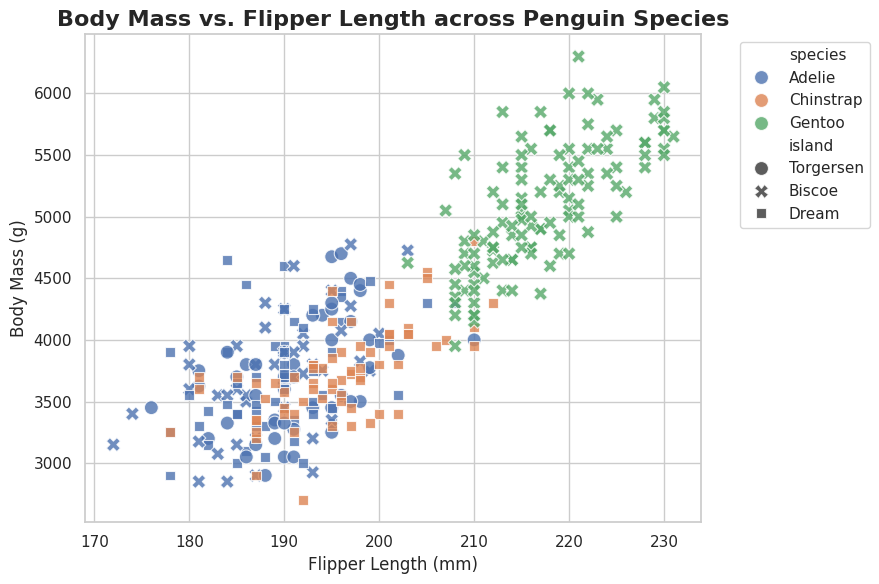

In [3]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g', hue='species', style='island', s=100, alpha=0.8)
plt.title('Body Mass vs. Flipper Length across Penguin Species', fontsize=16, weight='bold')
plt.xlabel('Flipper Length (mm)', fontsize=12)
plt.ylabel('Body Mass (g)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Narrative Insight:**
A strong positive correlation exists between flipper length and body mass. The **Gentoo** penguins form a distinct, separate cluster in the upper-right quadrant, indicating they are significantly larger and heavier than the other two species. Adelie and Chinstrap penguins overlap considerably in body mass and flipper length, prompting the need for further anatomical investigation to differentiate them.

### Visualization 3: Differentiating the Overlap (Bill Dimensions)
Since Adelie and Chinstrap penguins overlap in mass and flipper length, we examine their bill (culmen) length using a violin plot to observe distribution density and median values simultaneously.

/tmp/ipykernel_1346/3625797803.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=penguins, x='species', y='bill_length_mm', palette='Set2', inner='quartile')


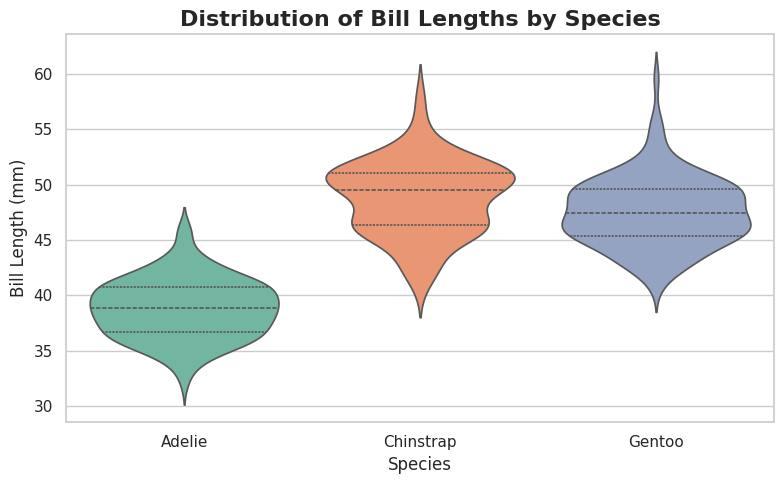

In [4]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=penguins, x='species', y='bill_length_mm', palette='Set2', inner='quartile')
plt.title('Distribution of Bill Lengths by Species', fontsize=16, weight='bold')
plt.xlabel('Species', fontsize=12)
plt.ylabel('Bill Length (mm)', fontsize=12)
plt.tight_layout()
plt.show()

**Narrative Insight:**
The violin plot successfully isolates the previously overlapping species. While Adelie and Chinstrap share similar body masses, the **Chinstrap** penguins possess significantly longer bills (averaging ~50mm) compared to the **Adelie** (~38mm). This visualization demonstrates the importance of multi-dimensional feature analysis when classifying biological data.

### Visualization 4: Synthesizing Physical Metrics (Correlation Heatmap)
To conclude our analysis, we condense the relationships between all numerical features into a single correlation heatmap.

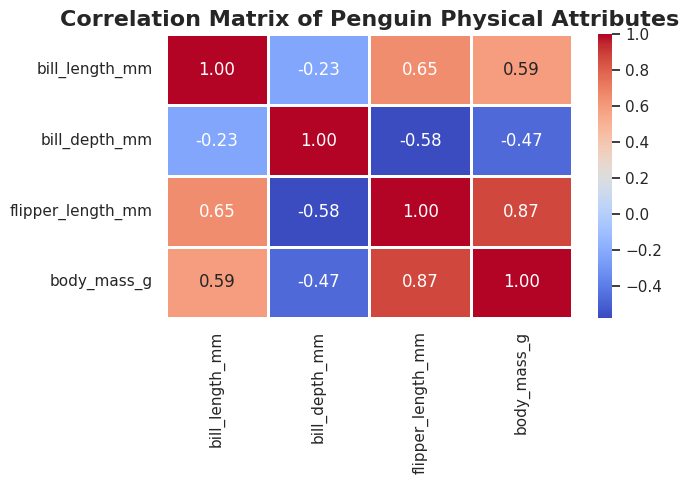

In [5]:
# Select only numerical columns for correlation
numerical_penguins = penguins.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numerical_penguins.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
plt.title('Correlation Matrix of Penguin Physical Attributes', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

**Narrative Insight & Final Conclusion:**
The heatmap confirms our visual findings quantitatively. The strongest correlation (0.87) exists between flipper length and body mass, cementing the visual trend seen in Visualization 2. Conversely, bill depth exhibits a negative correlation with body mass (-0.47) and flipper length (-0.58).

**Overall Summary:**
Through this visual portfolio, we successfully translated raw ecological data into a clear biological narrative. We established the geographic boundaries of three penguin species, identified the Gentoo as physically distinct through mass and flipper size, differentiated the remaining two species via bill dimensions, and validated these trends statistically. The progression of these visuals demonstrates a structured, exploratory approach to data communication.